In [1]:
pip install pandas numpy matplotlib seaborn scipy statsmodels yfinance selenium webdriver-manager

  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached webdriver_manager-4.0.2-py2.py3-none-any.whl.metadata (12 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Usi

#### Import packages and libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import yfinance as yf
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager

#### Download Benchmark Data

In [3]:
import yfinance as yf
import pandas as pd

# S&P 500 (developed market benchmark)
sp500 = yf.download('^GSPC', start='2015-01-01', end='2025-12-31')
sp500.to_csv('../data/raw/benchmarks/sp500_benchmark.csv')

# MSCI Emerging Markets
msci_em = yf.download('EEM', start='2015-01-01', end='2025-12-31')
msci_em.to_csv('../data/raw/benchmarks/msci_em_benchmark.csv')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


#### Data cleaning and transformation

In [6]:
import os
from datetime import datetime

def load_and_clean_stock_data(filepath):
    """Load and clean Investing.com CSV data"""
    try:
        # Read CSV
        df = pd.read_csv(filepath)
        
        # Convert date
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
        df = df.sort_values('Date')
        
        # Rename columns
        df = df.rename(columns={
            'Price': 'Close',
            'Vol.': 'Volume'
        })
        
        # Convert price columns to numeric (remove commas)
        for col in ['Open', 'High', 'Low', 'Close']:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
        
        # Clean volume
        if 'Volume' in df.columns:
            df['Volume'] = df['Volume'].replace('-', '0')
            df['Volume'] = pd.to_numeric(df['Volume'].astype(str).str.replace('K', '').str.replace('M', ''), errors='coerce')
        
        # Keep only necessary columns
        df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
        
        # Remove rows with missing prices
        df = df.dropna(subset=['Close'])
        
        # Set date as index
        df.set_index('Date', inplace=True)
        
        return df
    
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def calculate_returns(df):
    """Calculate daily and cumulative returns"""
    df['Returns'] = df['Close'].pct_change()
    df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Cumulative_Returns'] = (1 + df['Returns']).cumprod() - 1
    return df

In [8]:
# Load all stocks
stock_folder = '../data/raw/ngx_stocks'
stocks = {}

for filename in os.listdir(stock_folder):
    if filename.endswith('.csv'):
        symbol = filename.replace(' Historical Data.csv', '').replace('_cleaned.csv', '')
        filepath = os.path.join(stock_folder, filename)
        
        df = load_and_clean_stock_data(filepath)
        if df is not None and len(df) > 252:  # At least 1 year of data
            df = calculate_returns(df)
            stocks[symbol] = df
            print(f"✓ Loaded {symbol}: {len(df)} days, {df.index.min()} to {df.index.max()}")

print(f"\nTotal stocks loaded: {len(stocks)}")

# Save cleaned data
for symbol, df in stocks.items():
    df.to_csv(f'../data/processed/{symbol}_clean.csv')

✓ Loaded DANGCEM: 2721 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded DANGSUG: 2722 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded ETI: 2721 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded FCMB: 2722 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded FIDELIT: 2722 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded FIRSTHOLD: 2721 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded GTCO: 2718 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded GUINNES: 2722 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded IBTC: 2720 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded INTBREW: 2708 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded NB: 2722 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded NESTLE: 2721 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded OKOMUOI: 2721 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded PRESCO: 2689 days, 2015-01-05 00:00:00 to 2025-12-31 00:00:00
✓ Loaded S

#### Creating Data Quality Report


DATA QUALITY REPORT
        Symbol Start_Date   End_Date  Total_Days  Missing_Volume  Zero_Volume_Days   Mean_Price  Max_Price  Min_Price  Mean_Return  Volatility
0      DANGCEM 2015-01-05 2025-12-31        2721               0                 0   271.834109     763.00     116.80     0.162815    0.331487
1      DANGSUG 2015-01-05 2025-12-31        2722               0                 0    20.870720      82.65       5.10     0.320952    0.466607
2          ETI 2015-01-05 2025-12-31        2721               1                 0    15.191801      42.00       3.90     0.189377    0.460728
3         FCMB 2015-01-05 2025-12-31        2722               3                 0     3.742296      12.05       0.71     0.275096    0.510304
4      FIDELIT 2015-01-05 2025-12-31        2722               2                 0     4.921525      21.70       0.76     0.346557    0.487169
5    FIRSTHOLD 2015-01-05 2025-12-31        2721               1                 0    11.754146      53.00       2.95    

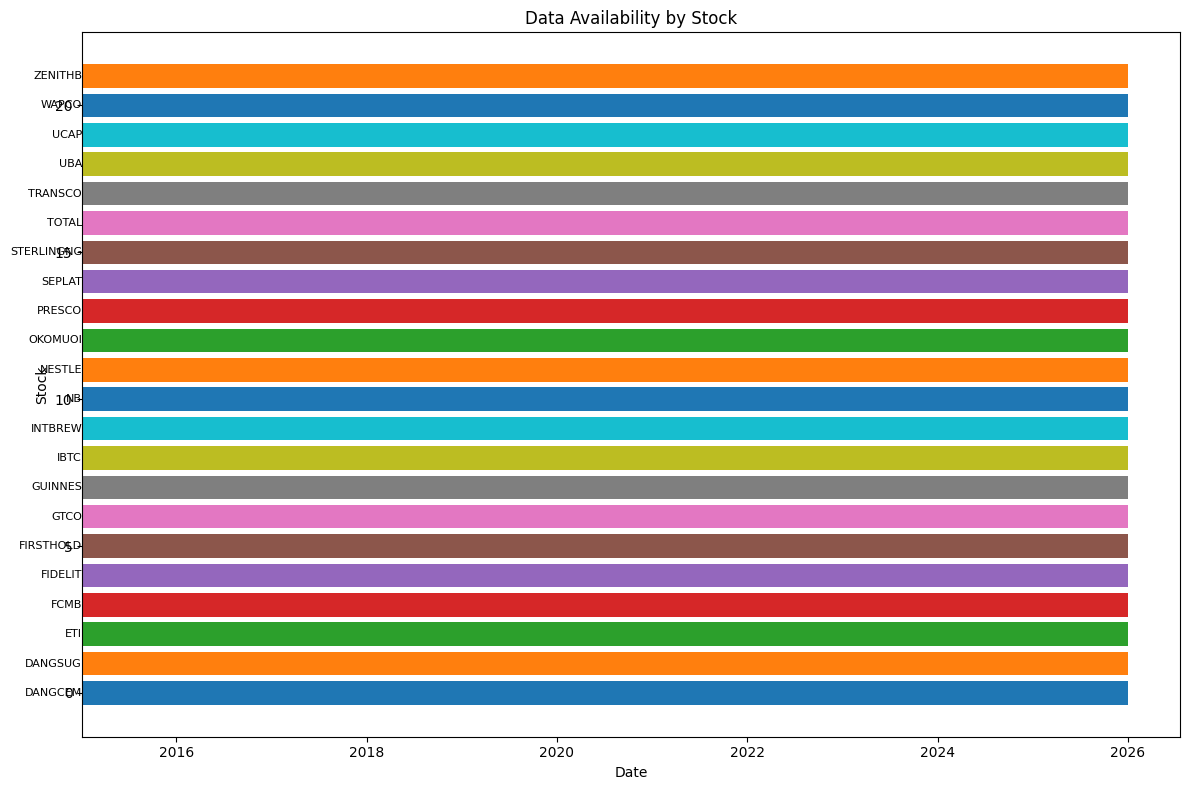

In [9]:
def create_data_quality_report(stocks):
    """Generate comprehensive data quality report"""
    
    report = []
    
    for symbol, df in stocks.items():
        stats = {
            'Symbol': symbol,
            'Start_Date': df.index.min(),
            'End_Date': df.index.max(),
            'Total_Days': len(df),
            'Missing_Volume': df['Volume'].isna().sum(),
            'Zero_Volume_Days': (df['Volume'] == 0).sum(),
            'Mean_Price': df['Close'].mean(),
            'Max_Price': df['Close'].max(),
            'Min_Price': df['Close'].min(),
            'Mean_Return': df['Returns'].mean() * 252,  # Annualized
            'Volatility': df['Returns'].std() * np.sqrt(252),  # Annualized
        }
        report.append(stats)
    
    report_df = pd.DataFrame(report)
    report_df.to_csv('../data/processed/data_quality_report.csv', index=False)
    
    print("\n" + "="*60)
    print("DATA QUALITY REPORT")
    print("="*60)
    print(report_df.to_string())
    
    return report_df

# Generate report
quality_report = create_data_quality_report(stocks)

# Visualization: Data availability timeline
fig, ax = plt.subplots(figsize=(12, 8))
for i, (symbol, df) in enumerate(stocks.items()):
    ax.barh(i, (df.index.max() - df.index.min()).days, 
            left=df.index.min(), height=0.8)
    ax.text(df.index.min(), i, symbol, va='center', ha='right', fontsize=8)

ax.set_xlabel('Date')
ax.set_ylabel('Stock')
ax.set_title('Data Availability by Stock')
plt.tight_layout()
plt.savefig('../results/figures/data_availability.png', dpi=300)
plt.show()

#### Distributional Analysis

In [10]:
from scipy import stats
from scipy.stats import jarque_bera, shapiro, kstest

def analyze_return_distributions(stocks):
    """Comprehensive return distribution analysis"""
    
    results = []
    
    for symbol, df in stocks.items():
        returns = df['Returns'].dropna()
        
        # Basic statistics
        mean_ret = returns.mean()
        std_ret = returns.std()
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Normality tests
        jb_stat, jb_pvalue = jarque_bera(returns)
        
        # Tail statistics
        var_95 = returns.quantile(0.05)  # 5% VaR
        cvar_95 = returns[returns <= var_95].mean()  # CVaR
        
        results.append({
            'Symbol': symbol,
            'Mean': mean_ret,
            'Std': std_ret,
            'Skewness': skewness,
            'Kurtosis': kurtosis,
            'JB_Stat': jb_stat,
            'JB_pValue': jb_pvalue,
            'Is_Normal': jb_pvalue > 0.05,
            'VaR_95': var_95,
            'CVaR_95': cvar_95
        })
    
    dist_df = pd.DataFrame(results)
    dist_df.to_csv('../results/return_distributions.csv', index=False)
    
    return dist_df

# Run analysis
distribution_analysis = analyze_return_distributions(stocks)

print("\nReturn Distribution Summary:")
print(f"Stocks with Normal distribution: {distribution_analysis['Is_Normal'].sum()}/{len(distribution_analysis)}")
print(f"Average Skewness: {distribution_analysis['Skewness'].mean():.3f}")
print(f"Average Excess Kurtosis: {distribution_analysis['Kurtosis'].mean():.3f}")


Return Distribution Summary:
Stocks with Normal distribution: 0/22
Average Skewness: 1.394
Average Excess Kurtosis: 51.765


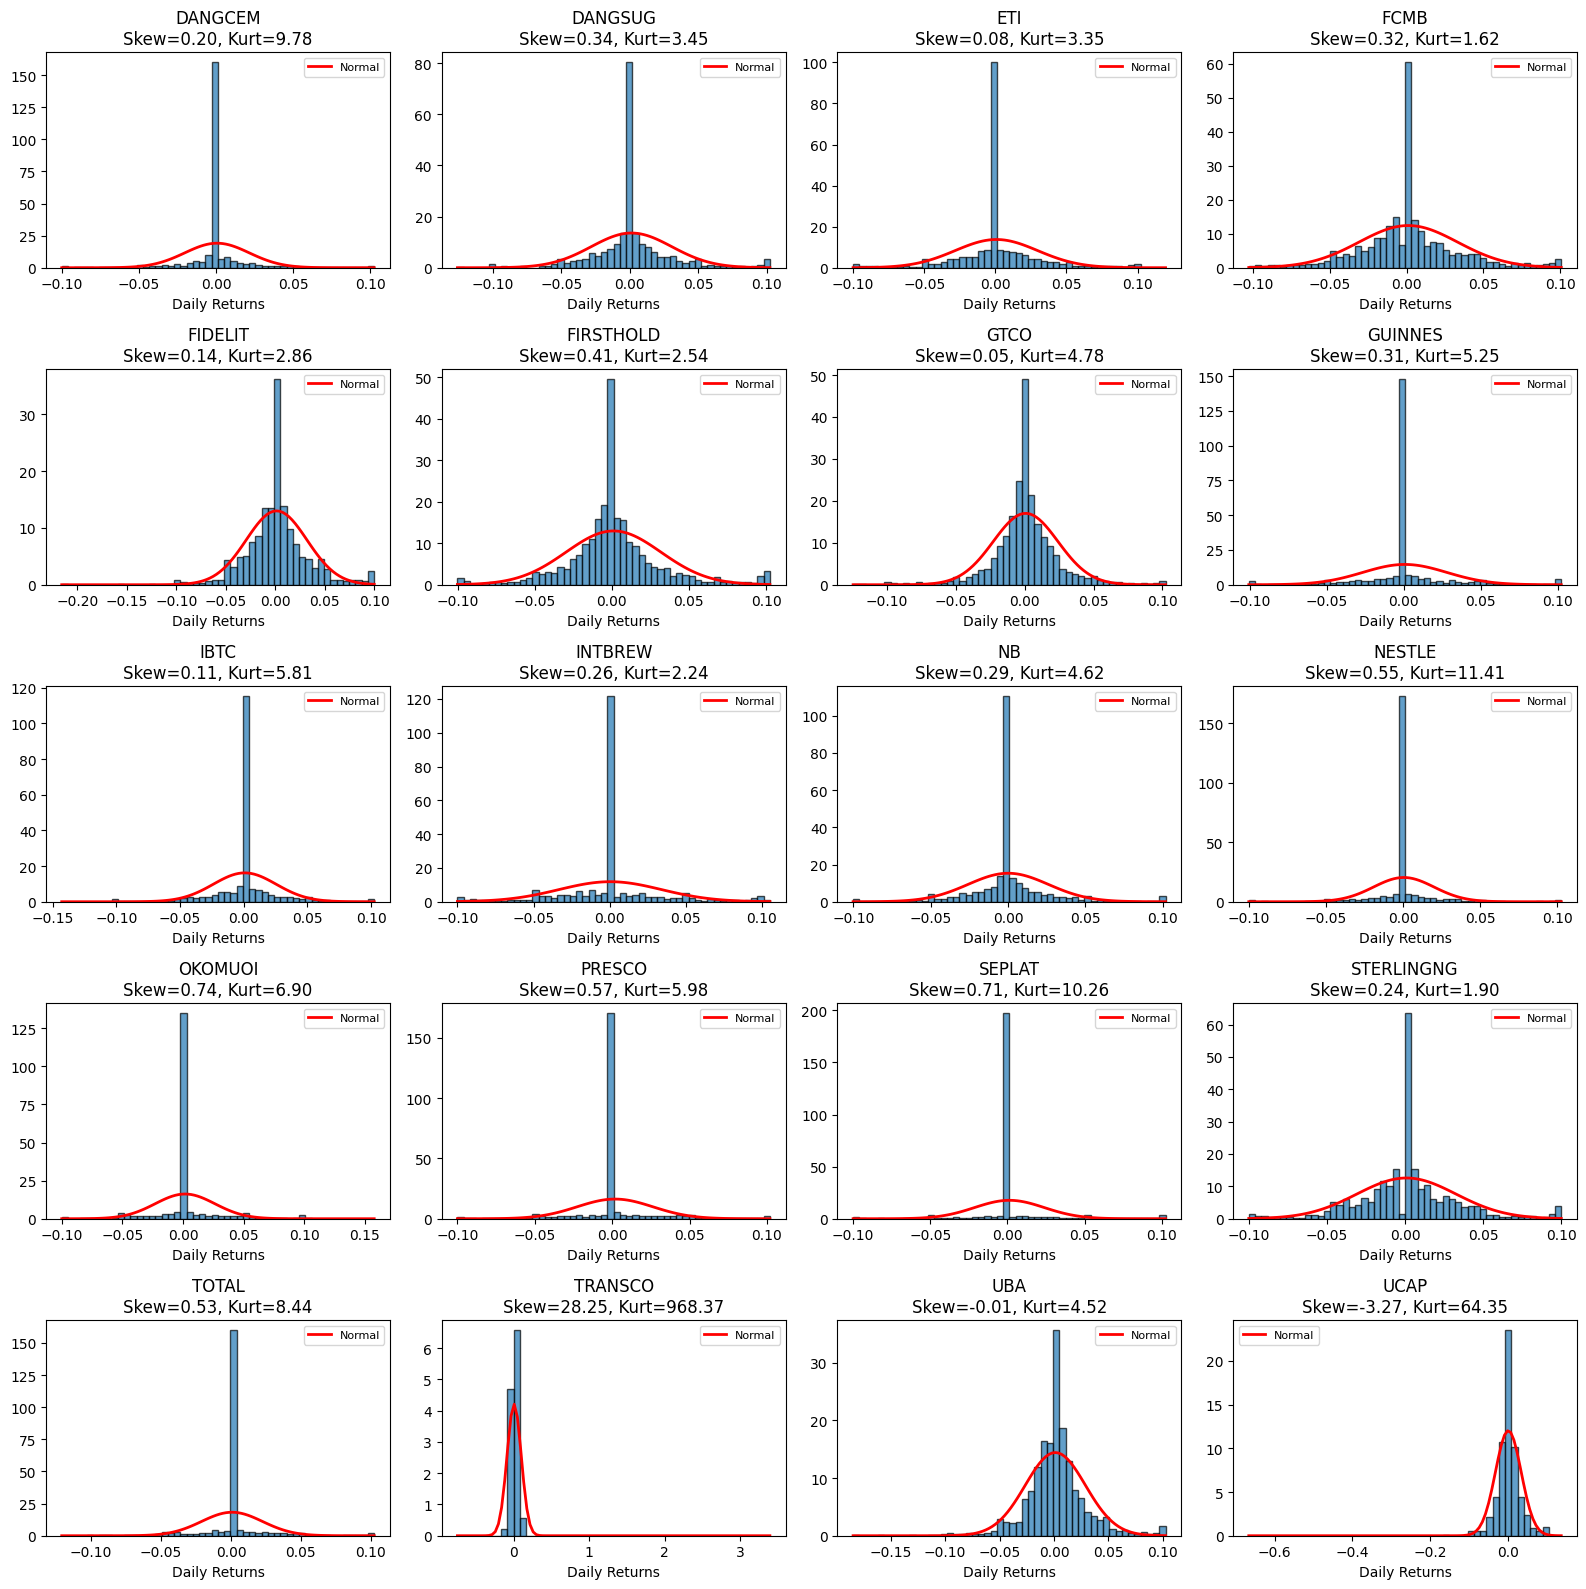

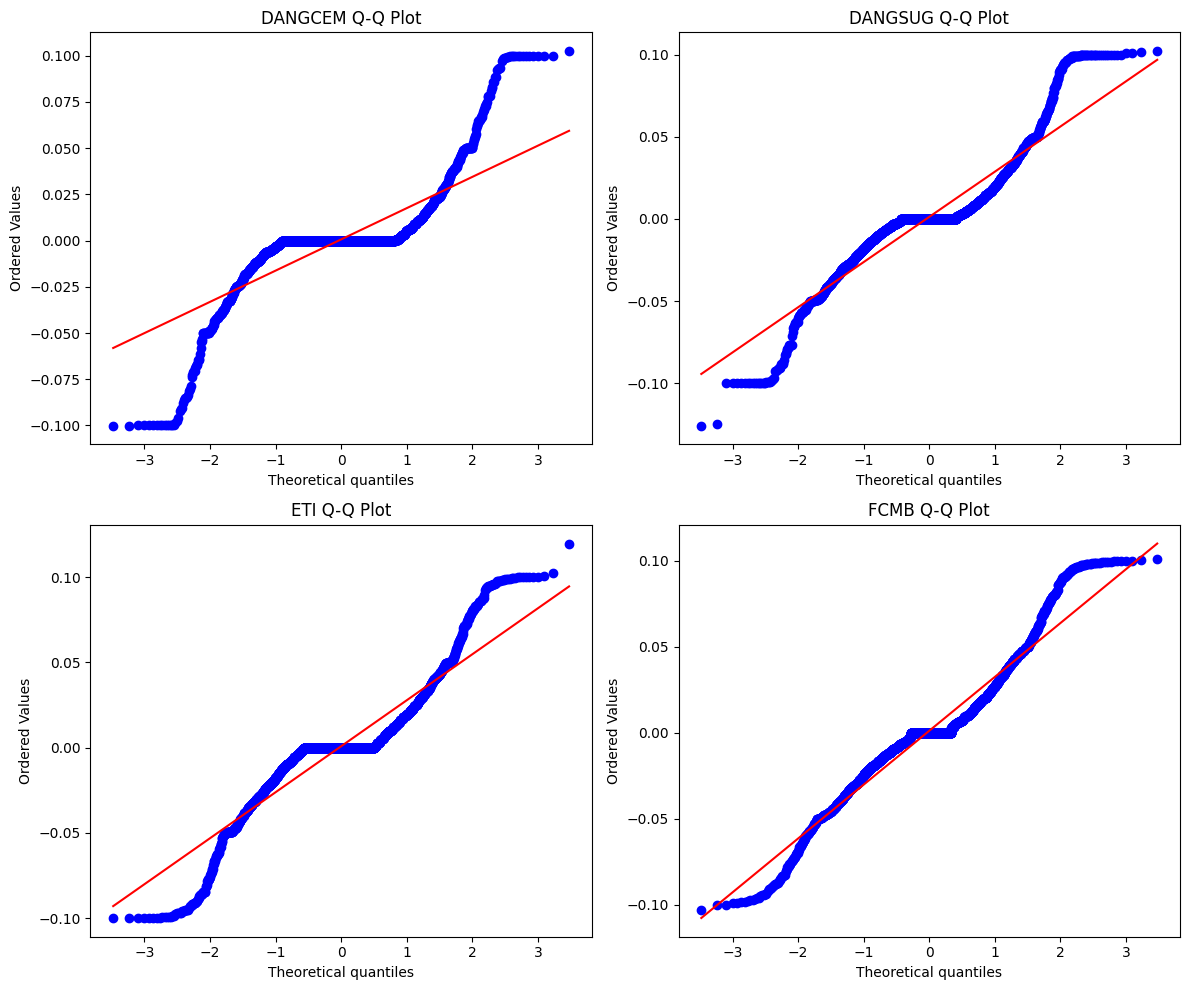

In [11]:
# Create distribution plots
fig, axes = plt.subplots(5, 4, figsize=(16, 16))
axes = axes.flatten()

for i, (symbol, df) in enumerate(list(stocks.items())[:20]):
    returns = df['Returns'].dropna()
    
    axes[i].hist(returns, bins=50, density=True, alpha=0.7, edgecolor='black')
    
    # Overlay normal distribution
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    axes[i].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
    
    axes[i].set_title(f'{symbol}\nSkew={returns.skew():.2f}, Kurt={returns.kurtosis():.2f}')
    axes[i].set_xlabel('Daily Returns')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/figures/return_distributions.png', dpi=300)
plt.show()

# Q-Q plots for top 4 stocks
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (symbol, df) in enumerate(list(stocks.items())[:4]):
    returns = df['Returns'].dropna()
    stats.probplot(returns, dist="norm", plot=axes[i])
    axes[i].set_title(f'{symbol} Q-Q Plot')

plt.tight_layout()
plt.savefig('../results/figures/qq_plots.png', dpi=300)
plt.show()

#### Comparative Analysis

In [12]:
def compare_with_benchmarks(ngx_stocks, sp500_df, msci_em_df):
    """Compare NGX with developed and emerging market benchmarks"""
    
    # Calculate NGX composite (equal-weight)
    ngx_returns = pd.DataFrame({symbol: df['Returns'] for symbol, df in ngx_stocks.items()})
    ngx_composite = ngx_returns.mean(axis=1)
    
    # Calculate benchmark returns
    sp500_df['Returns'] = sp500_df['Close'].pct_change()
    msci_em_df['Returns'] = msci_em_df['Close'].pct_change()
    
    # Statistics
    comparison = {
        'Market': ['NGX (Composite)', 'S&P 500', 'MSCI EM'],
        'Mean_Return': [
            ngx_composite.mean() * 252,
            sp500_df['Returns'].mean() * 252,
            msci_em_df['Returns'].mean() * 252
        ],
        'Volatility': [
            ngx_composite.std() * np.sqrt(252),
            sp500_df['Returns'].std() * np.sqrt(252),
            msci_em_df['Returns'].std() * np.sqrt(252)
        ],
        'Sharpe_Ratio': [
            (ngx_composite.mean() / ngx_composite.std()) * np.sqrt(252),
            (sp500_df['Returns'].mean() / sp500_df['Returns'].std()) * np.sqrt(252),
            (msci_em_df['Returns'].mean() / msci_em_df['Returns'].std()) * np.sqrt(252)
        ],
        'Skewness': [
            ngx_composite.skew(),
            sp500_df['Returns'].skew(),
            msci_em_df['Returns'].skew()
        ],
        'Kurtosis': [
            ngx_composite.kurtosis(),
            sp500_df['Returns'].kurtosis(),
            msci_em_df['Returns'].kurtosis()
        ]
    }
    
    comp_df = pd.DataFrame(comparison)
    comp_df.to_csv('../results/market_comparison.csv', index=False)
    
    print("\n" + "="*60)
    print("MARKET COMPARISON")
    print("="*60)
    print(comp_df.to_string(index=False))
    
    return comp_df

# Run comparison
market_comparison = compare_with_benchmarks(stocks, sp500, msci_em)


MARKET COMPARISON
         Market  Mean_Return  Volatility  Sharpe_Ratio  Skewness  Kurtosis
NGX (Composite)     0.265024    0.189960      1.395159  1.616607 18.645186
        S&P 500     0.126354    0.179117      0.705430 -0.363924 15.098605
        MSCI EM     0.074951    0.204257      0.366944 -0.496258  7.896081


#### Volatility Analysis

In [13]:
pip install arch

   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/934.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/934.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/934.4 kB ? eta -:--:--
   --------------------- ---------------- 524.3/934.4 kB 692.4 kB/s eta 0:00:01
   ------------------------------- ------ 786.4/934.4 kB 745.7 kB/s eta 0:00:01
   ------------------------------- ------ 786.4/934.4 kB 745.7 kB/s eta 0:00:01
   ---------------------------------------- 934.4/934.4 kB 618.3 kB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.


In [14]:
from arch import arch_model

def analyze_volatility(stocks):
    """Comprehensive volatility analysis"""
    
    volatility_results = []
    
    for symbol, df in stocks.items():
        returns = df['Returns'].dropna() * 100  # Convert to percentage
        
        # Rolling volatility
        df['Vol_30d'] = df['Returns'].rolling(30).std() * np.sqrt(252)
        df['Vol_60d'] = df['Returns'].rolling(60).std() * np.sqrt(252)
        
        # GARCH(1,1) model
        try:
            model = arch_model(returns, vol='Garch', p=1, q=1)
            garch_fit = model.fit(disp='off')
            
            volatility_results.append({
                'Symbol': symbol,
                'Mean_Vol': df['Vol_30d'].mean(),
                'Max_Vol': df['Vol_30d'].max(),
                'Min_Vol': df['Vol_30d'].min(),
                'GARCH_omega': garch_fit.params['omega'],
                'GARCH_alpha': garch_fit.params['alpha[1]'],
                'GARCH_beta': garch_fit.params['beta[1]'],
                'Persistence': garch_fit.params['alpha[1]'] + garch_fit.params['beta[1]']
            })
        except:
            print(f"GARCH failed for {symbol}")
    
    vol_df = pd.DataFrame(volatility_results)
    vol_df.to_csv('../results/volatility_analysis.csv', index=False)
    
    return vol_df

# Run analysis
volatility_analysis = analyze_volatility(stocks)

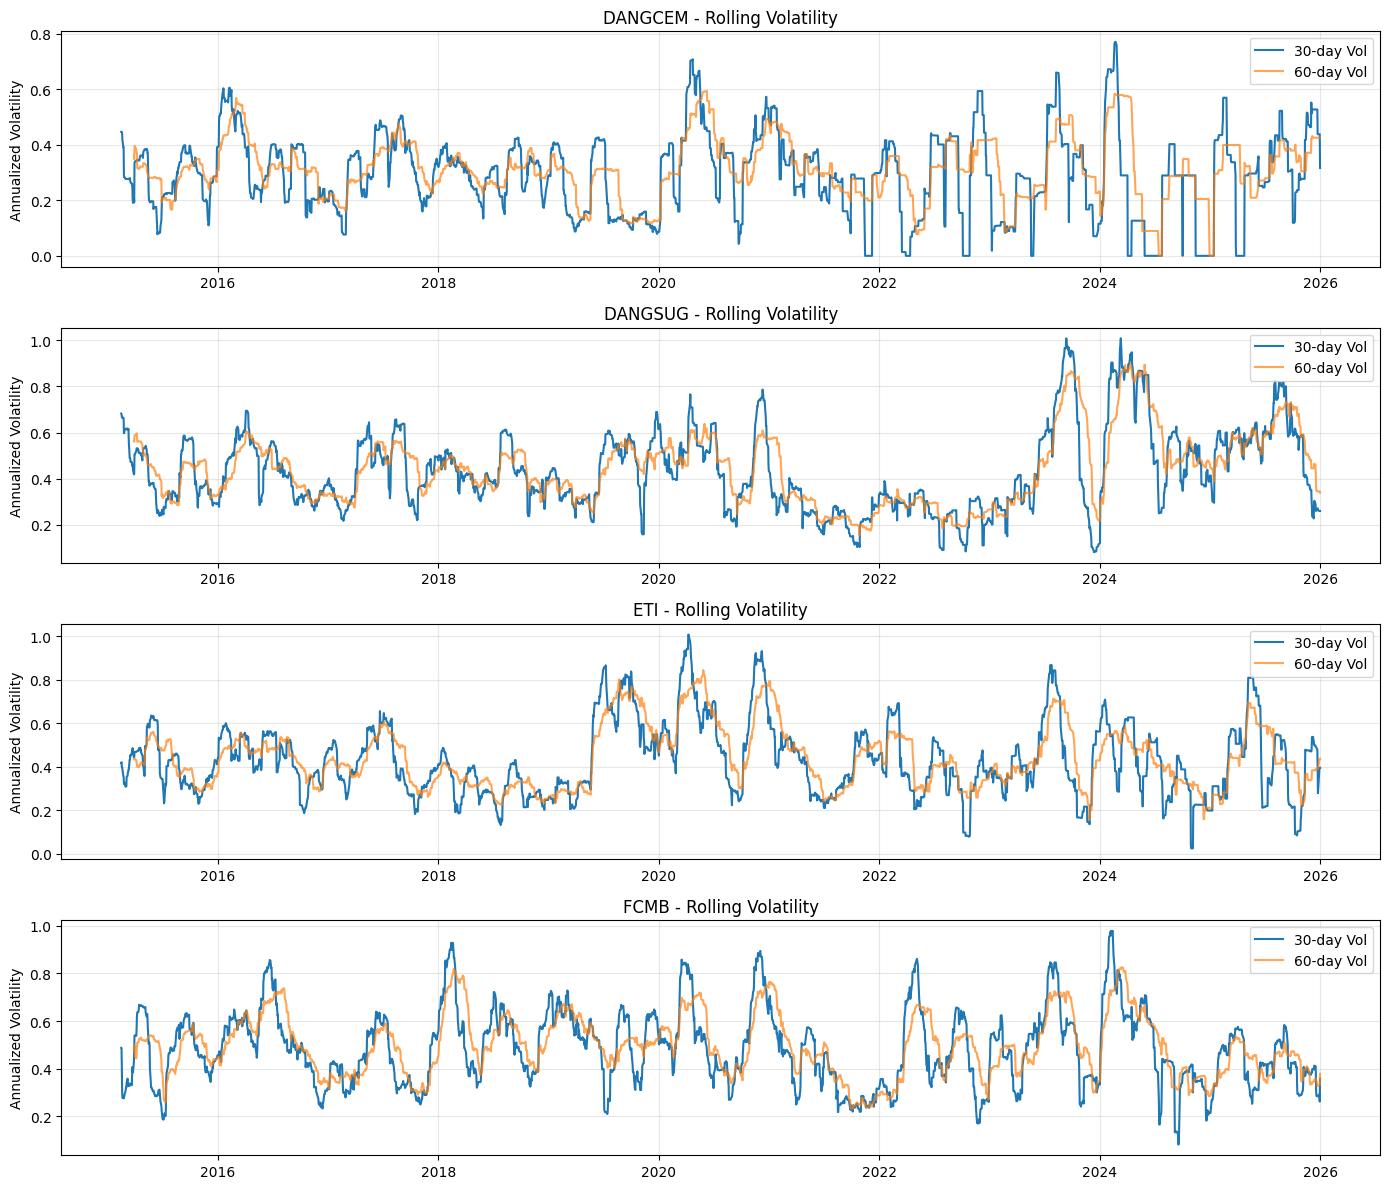

In [15]:
# Time-varying volatility plots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

sample_stocks = list(stocks.keys())[:4]

for i, symbol in enumerate(sample_stocks):
    df = stocks[symbol]
    axes[i].plot(df.index, df['Vol_30d'], label='30-day Vol', linewidth=1.5)
    axes[i].plot(df.index, df['Vol_60d'], label='60-day Vol', linewidth=1.5, alpha=0.7)
    axes[i].set_title(f'{symbol} - Rolling Volatility')
    axes[i].set_ylabel('Annualized Volatility')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/rolling_volatility.png', dpi=300)
plt.show()

#### Regime Analysis

In [16]:
def identify_volatility_regimes(stocks):
    """Identify high/low volatility periods"""
    
    # Calculate market-wide volatility
    all_returns = pd.DataFrame({symbol: df['Returns'] for symbol, df in stocks.items()})
    market_vol = all_returns.std(axis=1).rolling(20).mean()
    
    # Define regimes (simple threshold method)
    high_vol_threshold = market_vol.quantile(0.75)
    low_vol_threshold = market_vol.quantile(0.25)
    
    regimes = []
    regimes.append(market_vol > high_vol_threshold)  # High vol
    regimes.append(market_vol < low_vol_threshold)   # Low vol
    
    print(f"High Volatility Periods: {(market_vol > high_vol_threshold).sum()} days")
    print(f"Low Volatility Periods: {(market_vol < low_vol_threshold).sum()} days")
    
    return market_vol, high_vol_threshold, low_vol_threshold

#### Liquidity Analysis

In [17]:
def analyze_liquidity(stocks):
    """Analyze market liquidity characteristics"""
    
    liquidity_results = []
    
    for symbol, df in stocks.items():
        # Basic liquidity metrics
        zero_vol_days = (df['Volume'] == 0).sum()
        zero_vol_pct = zero_vol_days / len(df) * 100
        
        avg_volume = df['Volume'].mean()
        med_volume = df['Volume'].median()
        vol_std = df['Volume'].std()
        
        # Turnover (approximation without market cap data)
        # Using volume as proxy
        
        liquidity_results.append({
            'Symbol': symbol,
            'Avg_Volume': avg_volume,
            'Median_Volume': med_volume,
            'Vol_Std': vol_std,
            'Zero_Vol_Days': zero_vol_days,
            'Zero_Vol_Pct': zero_vol_pct,
            'Coefficient_of_Variation': vol_std / avg_volume if avg_volume > 0 else np.nan
        })
    
    liq_df = pd.DataFrame(liquidity_results)
    liq_df = liq_df.sort_values('Avg_Volume', ascending=False)
    liq_df.to_csv('../results/liquidity_analysis.csv', index=False)
    
    return liq_df

# Run analysis
liquidity_analysis = analyze_liquidity(stocks)

print("\nLiquidity Summary:")
print(f"Most liquid stock: {liquidity_analysis.iloc[0]['Symbol']}")
print(f"Least liquid stock: {liquidity_analysis.iloc[-1]['Symbol']}")
print(f"Average zero-volume days: {liquidity_analysis['Zero_Vol_Pct'].mean():.2f}%")


Liquidity Summary:
Most liquid stock: NB
Least liquid stock: GTCO
Average zero-volume days: 0.01%


#### Correlation Analysis


Correlation Analysis:
Average pairwise correlation: 0.109
Maximum correlation: 0.581
Minimum correlation: -0.041


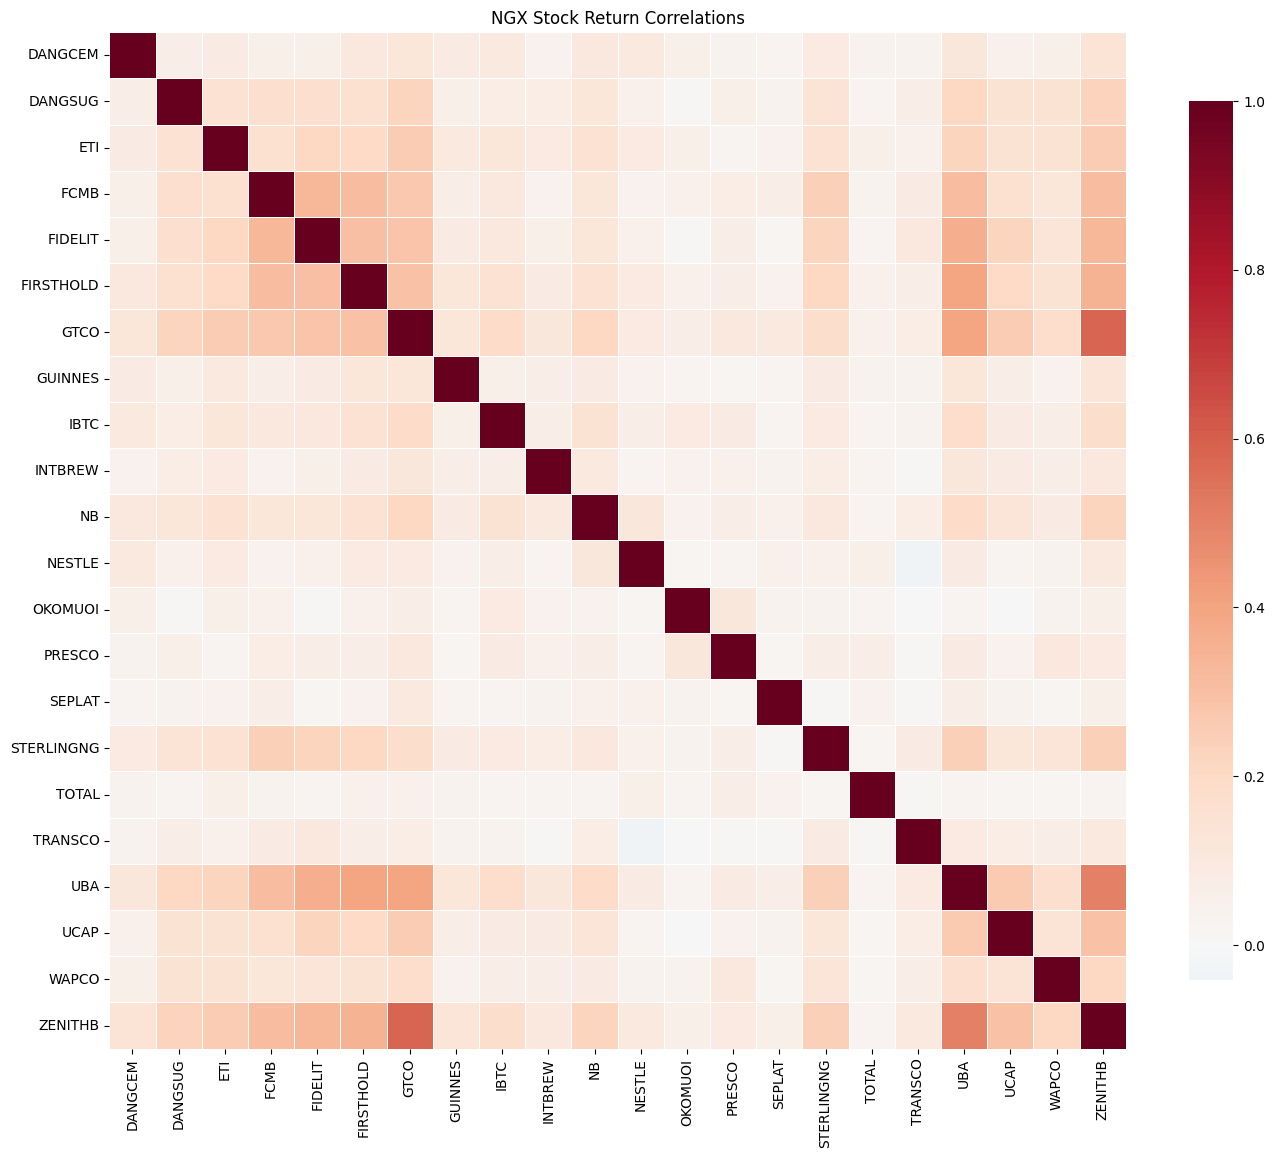

In [18]:
def analyze_correlations(stocks):
    """Calculate and analyze correlation structure"""
    
    # Create returns matrix
    returns_matrix = pd.DataFrame({symbol: df['Returns'] for symbol, df in stocks.items()})
    returns_matrix = returns_matrix.dropna()
    
    # Full period correlation
    corr_matrix = returns_matrix.corr()
    corr_matrix.to_csv('../results/correlation_matrix.csv')
    
    # Summary statistics
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    avg_corr = upper_triangle.stack().mean()
    max_corr = upper_triangle.stack().max()
    min_corr = upper_triangle.stack().min()
    
    print("\nCorrelation Analysis:")
    print(f"Average pairwise correlation: {avg_corr:.3f}")
    print(f"Maximum correlation: {max_corr:.3f}")
    print(f"Minimum correlation: {min_corr:.3f}")
    
    # Visualize
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('NGX Stock Return Correlations')
    plt.tight_layout()
    plt.savefig('../results/figures/correlation_heatmap.png', dpi=300)
    plt.show()
    
    return corr_matrix, avg_corr

# Run analysis
corr_matrix, avg_corr = analyze_correlations(stocks)

#### Market Efficiency

In [19]:
from statsmodels.tsa.stattools import adfuller

def test_market_efficiency(stocks):
    """Test for market efficiency using various methods"""
    
    efficiency_results = []
    
    for symbol, df in stocks.items():
        returns = df['Returns'].dropna()
        
        # Autocorrelation test
        autocorr_lag1 = returns.autocorr(lag=1)
        
        # ADF test (unit root)
        adf_result = adfuller(df['Close'].dropna())
        
        # Runs test (simplified)
        positive_runs = (returns > 0).astype(int)
        sign_changes = (positive_runs.diff() != 0).sum()
        
        efficiency_results.append({
            'Symbol': symbol,
            'Autocorr_Lag1': autocorr_lag1,
            'ADF_Statistic': adf_result[0],
            'ADF_pValue': adf_result[1],
            'Is_Stationary': adf_result[1] < 0.05,
            'Sign_Changes': sign_changes
        })
    
    eff_df = pd.DataFrame(efficiency_results)
    eff_df.to_csv('../results/efficiency_tests.csv', index=False)
    
    return eff_df

# Run tests
efficiency_tests = test_market_efficiency(stocks)

#### Key Findings to Highlight

In [20]:
def generate_summary_report(all_results):
    """Generate final summary report for IndabaX submission"""
    
    summary = {
        'Research Questions Addressed': 'RQ4 - Market Characterization',
        'Dataset': f'{len(stocks)} NGX stocks, 2015-2025',
        'Key Findings': [
            f"Average volatility: {volatility_analysis['Mean_Vol'].mean():.1f}% (vs S&P 500: ~15%)",
            f"Non-normal returns: {(distribution_analysis['Is_Normal'] == False).sum()}/{len(distribution_analysis)} stocks",
            f"Average correlation: {avg_corr:.3f}",
            f"Liquidity constraints: {liquidity_analysis['Zero_Vol_Pct'].mean():.1f}% zero-volume days",
            "Evidence of volatility clustering (GARCH persistence > 0.9)",
            "Market shows characteristics requiring specialized ML approaches"
        ]
    }
    
    return summary